<a href="https://colab.research.google.com/github/deshmukhvaishnavi04/celebal-internship/blob/main/Week4_Vaishnavi_deshmukh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Image Classification on CIFAR-10 using ANN and CNN


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


###Dataset Load

In [9]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 140s 1us/step
Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


###Visualize Images

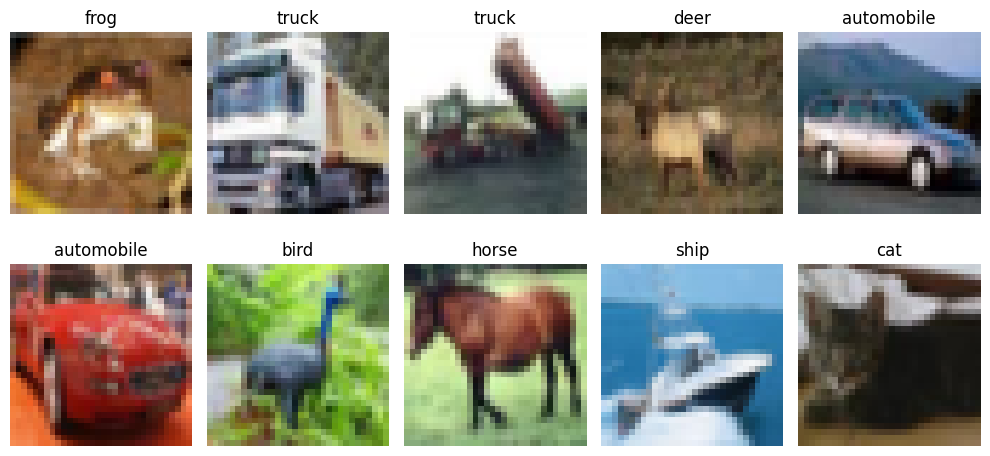

In [10]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

###Data Preprocessing

In [11]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

###ANN Model


In [12]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###Train ANN

In [13]:
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.2727 - loss: 1.9906 - val_accuracy: 0.3366 - val_loss: 1.8590
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - accuracy: 0.3188 - loss: 1.8667 - val_accuracy: 0.3610 - val_loss: 1.8031
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3399 - loss: 1.8171 - val_accuracy: 0.3642 - val_loss: 1.7515
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3526 - loss: 1.7833 - val_accuracy: 0.3840 - val_loss: 1.7263
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3611 - loss: 1.7577 - val_accuracy: 0.3746 - val_loss: 1.7456
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3680 - loss: 1.7411 - val_accuracy: 0.4010 - val_loss: 1.6921
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3797 - loss: 1.7170 - val_accuracy: 0.4066 - val_loss: 1.6815
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3819 - loss: 1.7115 - 

###Evaluate ANN

In [14]:
ann_loss, ann_acc = ann_model.evaluate(
    x_test_flat,
    y_test
)

print("ANN Accuracy:", ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4362 - loss: 1.6138
ANN Accuracy: 0.43619999289512634


###CNN Model

In [15]:
cnn_model = models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation="relu"),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###Train CNN

In [16]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_history = cnn_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 119ms/step - accuracy: 0.4723 - loss: 1.4806 - val_accuracy: 0.5578 - val_loss: 1.2963
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 117ms/step - accuracy: 0.6102 - loss: 1.1109 - val_accuracy: 0.5640 - val_loss: 1.2909
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.6707 - loss: 0.9491 - val_accuracy: 0.6900 - val_loss: 0.8984
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 113ms/step - accuracy: 0.7115 - loss: 0.8298 - val_accuracy: 0.6788 - val_loss: 0.9582
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 113ms/step - accuracy: 0.7444 - loss: 0.7390 - val_accuracy: 0.6634 - val_loss: 0.9794
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 113ms/step - accuracy: 0.7670 - loss: 0.6605 - val_accuracy: 0.7118 - val_loss: 0.8680
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.7904 - loss: 0.5957 - val_accuracy: 0.7278 - val_loss: 0.8070
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 113ms/step - accuracy: 0.8098 - loss: 

###Evaluate CNN

In [17]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test,
    y_test
)

print("CNN Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6789 - loss: 1.1049
CNN Accuracy: 0.6789000034332275


###Compare Learning Curves

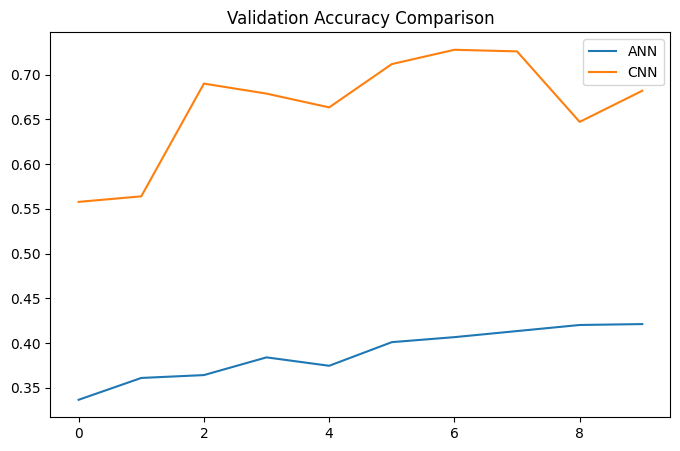

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    ann_history.history["val_accuracy"],
    label="ANN"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="CNN"
)

plt.legend()

plt.title("Validation Accuracy Comparison")

plt.show()

###Training Strategies

In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Optional Training
# aug_history = aug_cnn_model.fit(
#     x_train,
#     y_train,
#     epochs=10,
#     validation_split=0.1,
#     batch_size=64
# )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###Model Comparison

In [19]:
comparison = pd.DataFrame({
    "Model":["ANN","CNN"],
    "Accuracy":[ann_acc,cnn_acc]
})

comparison

,Model,Accuracy
0,ANN,0.4362
1,CNN,0.6789


 Both models were evaluated on the CIFAR-10 test dataset.
 The comparison shows that the CNN model achieved higher accuracy than the ANN model,
demonstrating its ability to learn spatial image features more effectively.

###Conclusion


This project successfully developed image classification models using both Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) on the CIFAR-10 dataset. The ANN model provided a baseline for classification, while the CNN achieved better performance by learning important spatial features from images. Training strategies such as Batch Normalization, Dropout, and Data Augmentation further improved the model's generalization and reduced overfitting. Overall, the comparison demonstrates that CNN is more effective than ANN for image classification tasks, making it a suitable choice for real-world computer vision applications.